# Iris(DBSCAN)

In [1]:
# step 1:import all the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

In [2]:
# step 2:Load the dataset
df = pd.read_csv(r"C:\Users\HARSHITHA\Desktop\FSDS\DBSCAN\Iris\Iris.csv")

In [3]:
# step 3:Data Exploration
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
# check the shape
df.shape

(150, 6)

In [5]:
# check the information
df.info

<bound method DataFrame.info of       Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm  \
0      1            5.1           3.5            1.4           0.2   
1      2            4.9           3.0            1.4           0.2   
2      3            4.7           3.2            1.3           0.2   
3      4            4.6           3.1            1.5           0.2   
4      5            5.0           3.6            1.4           0.2   
..   ...            ...           ...            ...           ...   
145  146            6.7           3.0            5.2           2.3   
146  147            6.3           2.5            5.0           1.9   
147  148            6.5           3.0            5.2           2.0   
148  149            6.2           3.4            5.4           2.3   
149  150            5.9           3.0            5.1           1.8   

            Species  
0       Iris-setosa  
1       Iris-setosa  
2       Iris-setosa  
3       Iris-setosa  
4       Iris-seto

In [6]:
# check the null and missing values
df.isnull().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [7]:
# check the duplicates
df.duplicated().sum()

np.int64(0)

In [9]:
# select feature for dbscan
features = [
    'SepalLengthCm',
    'SepalWidthCm',
    'PetalLengthCm',
    'PetalWidthCm'
]

X = df[features]

print(X.head())

   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
0            5.1           3.5            1.4           0.2
1            4.9           3.0            1.4           0.2
2            4.7           3.2            1.3           0.2
3            4.6           3.1            1.5           0.2
4            5.0           3.6            1.4           0.2


In [10]:
# feature scaling
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

[[-0.90068117  1.03205722 -1.3412724  -1.31297673]
 [-1.14301691 -0.1249576  -1.3412724  -1.31297673]
 [-1.38535265  0.33784833 -1.39813811 -1.31297673]
 [-1.50652052  0.10644536 -1.2844067  -1.31297673]
 [-1.02184904  1.26346019 -1.3412724  -1.31297673]]


In [11]:
# apply dbscan
dbscan = DBSCAN(
    eps=0.5,
    min_samples=5
)

labels = dbscan.fit_predict(X_scaled)

print(labels)

[ 0  0  0  0  0  0  0  0  0  0  0  0  0  0 -1 -1  0  0  0  0  0  0 -1  0
  0  0  0  0  0  0  0  0 -1 -1  0  0  0  0  0  0  0 -1  0  0  0  0  0  0
  0  0  1  1  1  1  1  1 -1 -1  1 -1 -1  1 -1  1  1  1  1  1 -1  1  1  1
 -1  1  1  1  1  1  1  1  1  1  1  1  1 -1  1 -1  1  1  1  1  1 -1  1  1
  1  1 -1  1 -1  1  1  1  1 -1 -1 -1 -1 -1  1  1  1  1 -1  1  1 -1 -1 -1
  1  1 -1  1  1 -1  1  1  1 -1 -1 -1  1  1  1 -1 -1  1  1  1  1  1  1  1
  1  1  1  1 -1  1]


In [12]:
# add cluster labels to the dataset
df['Cluster'] = labels

print(df.head())

   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species  \
0   1            5.1           3.5            1.4           0.2  Iris-setosa   
1   2            4.9           3.0            1.4           0.2  Iris-setosa   
2   3            4.7           3.2            1.3           0.2  Iris-setosa   
3   4            4.6           3.1            1.5           0.2  Iris-setosa   
4   5            5.0           3.6            1.4           0.2  Iris-setosa   

   Cluster  
0        0  
1        0  
2        0  
3        0  
4        0  


In [13]:
# find number of clusters
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

print("Number of clusters:", n_clusters)

Number of clusters: 2


In [14]:
# find noise points
noise_points = list(labels).count(-1)

print("Number of noise points:", noise_points)

Number of noise points: 35


In [15]:
# display cluster counts
print(df['Cluster'].value_counts())

Cluster
 1    71
 0    44
-1    35
Name: count, dtype: int64


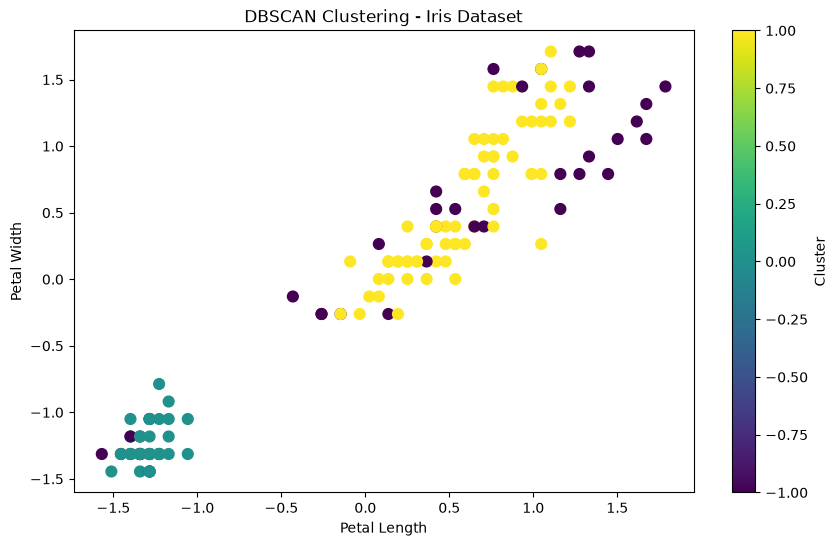

In [16]:
# visualize dbscan
plt.figure(figsize=(10, 6))

plt.scatter(
    X_scaled[:, 2],
    X_scaled[:, 3],
    c=labels,
    cmap='viridis',
    s=60
)

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("DBSCAN Clustering - Iris Dataset")

plt.colorbar(label="Cluster")

plt.show()

In [17]:
# calculate silhoute score
cluster_labels = set(labels) - {-1}

if len(cluster_labels) >= 2:

    score = silhouette_score(
        X_scaled,
        labels
    )

    print("Silhouette Score:", score)

else:

    print("Silhouette Score cannot be calculated because there are fewer than 2 clusters.")

Silhouette Score: 0.3491981656526392


In [18]:
# test different eps values
eps_values = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 1.0]

for eps in eps_values:

    model = DBSCAN(
        eps=eps,
        min_samples=5
    )

    labels_temp = model.fit_predict(X_scaled)

    clusters = len(set(labels_temp)) - (
        1 if -1 in labels_temp else 0
    )

    noise = list(labels_temp).count(-1)

    print(
        "eps =", eps,
        "| clusters =", clusters,
        "| noise =", noise
    )


eps = 0.2 | clusters = 0 | noise = 150
eps = 0.3 | clusters = 3 | noise = 120
eps = 0.4 | clusters = 6 | noise = 66
eps = 0.5 | clusters = 2 | noise = 35
eps = 0.6 | clusters = 2 | noise = 26
eps = 0.7 | clusters = 2 | noise = 8
eps = 0.8 | clusters = 2 | noise = 4
eps = 1.0 | clusters = 2 | noise = 3


In [19]:
pip install joblib

Note: you may need to restart the kernel to use updated packages.


In [20]:
import joblib
import os

In [23]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=0.5,
    min_samples=5
)

labels = dbscan.fit_predict(X_scaled)

print(labels)

[ 0  0  0  0  0  0  0  0  0  0  0  0  0  0 -1 -1  0  0  0  0  0  0 -1  0
  0  0  0  0  0  0  0  0 -1 -1  0  0  0  0  0  0  0 -1  0  0  0  0  0  0
  0  0  1  1  1  1  1  1 -1 -1  1 -1 -1  1 -1  1  1  1  1  1 -1  1  1  1
 -1  1  1  1  1  1  1  1  1  1  1  1  1 -1  1 -1  1  1  1  1  1 -1  1  1
  1  1 -1  1 -1  1  1  1  1 -1 -1 -1 -1 -1  1  1  1  1 -1  1  1 -1 -1 -1
  1  1 -1  1  1 -1  1  1  1 -1 -1 -1  1  1  1 -1 -1  1  1  1  1  1  1  1
  1  1  1  1 -1  1]


In [24]:
df["Cluster"] = labels

print(df.head())

   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species  \
0   1            5.1           3.5            1.4           0.2  Iris-setosa   
1   2            4.9           3.0            1.4           0.2  Iris-setosa   
2   3            4.7           3.2            1.3           0.2  Iris-setosa   
3   4            4.6           3.1            1.5           0.2  Iris-setosa   
4   5            5.0           3.6            1.4           0.2  Iris-setosa   

   Cluster  
0        0  
1        0  
2        0  
3        0  
4        0  


In [25]:
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

print("Number of Clusters:", n_clusters)

Number of Clusters: 2


In [26]:
noise_points = list(labels).count(-1)

print("Number of Noise Points:", noise_points)

Number of Noise Points: 35


In [27]:
print(df["Cluster"].value_counts())

Cluster
 1    71
 0    44
-1    35
Name: count, dtype: int64


In [28]:
from sklearn.metrics import silhouette_score

cluster_labels = set(labels) - {-1}

if len(cluster_labels) >= 2:
    score = silhouette_score(X_scaled, labels)
    print("Silhouette Score:", score)
else:
    print("Silhouette Score cannot be calculated.")

Silhouette Score: 0.3491981656526392


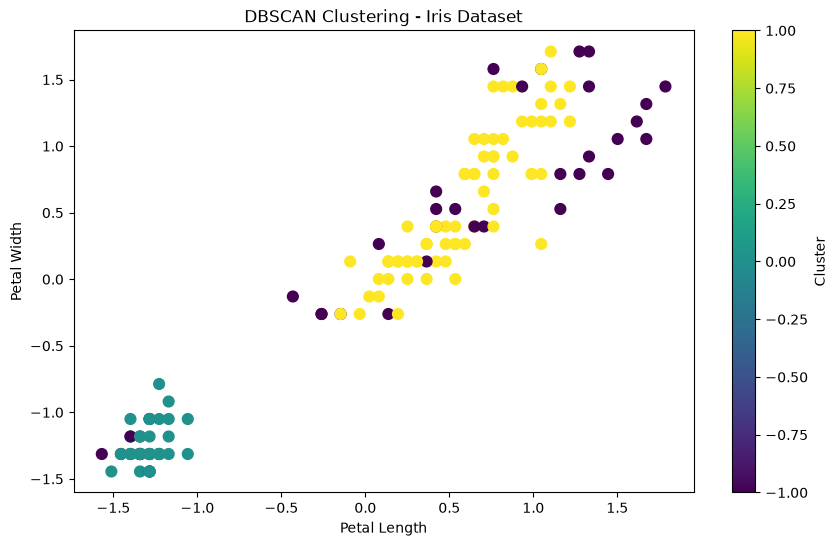

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(
    X_scaled[:, 2],
    X_scaled[:, 3],
    c=labels,
    cmap="viridis",
    s=60
)

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("DBSCAN Clustering - Iris Dataset")

plt.colorbar(label="Cluster")

plt.show()

In [30]:
df.to_csv("Iris_DBSCAN_Clustered.csv", index=False)

print("Dataset saved successfully!")

Dataset saved successfully!


In [31]:
import joblib

joblib.dump(dbscan, "dbscan_model.pkl")

print("DBSCAN model saved successfully!")

DBSCAN model saved successfully!


In [32]:
joblib.dump(scaler, "scaler.pkl")

print("Scaler saved successfully!")

Scaler saved successfully!
